# Kazan Temporal Amplitude Variants Review

Compare the legacy temporal normative with three SKU-level amplitude variants:
`weekly_cv`, `flat_deviation`, and `reference_profile`.

Current review focus:
- adaptive weekday share = long share corrected by short share
- short share window should be `28` days
- short share weight should be `0.5`
- check where adaptive share really moves the shape and where amplitude overreacts


In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 6)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"
TEMPORAL_PATH = DATA_DIR / "kazan_temporal_normative_sku_day.csv"
SUMMARY_PATH = DATA_DIR / "kazan_temporal_normative_sku_day_summary.json"

temporal = pd.read_csv(TEMPORAL_PATH, encoding="utf-8-sig", low_memory=False)
temporal["date"] = pd.to_datetime(temporal["date"], errors="coerce")
temporal.shape

(231695, 72)

## Summary


In [24]:
import json

summary_json = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))

summary = {
    "rows": len(temporal),
    "dates": temporal["date"].nunique(),
    "bakeries": temporal["bakery_id"].nunique(),
    "sku": temporal["product_id"].nunique(),
    "mean_observed": temporal["observed_sales_qty"].mean(),
    "mean_reconstructed": temporal["reconstructed_sales_qty"].mean(),
    "mean_legacy": temporal["temporal_normative_legacy_qty"].mean(),
    "mean_weekly_cv": temporal["temporal_normative_weekly_cv_qty"].mean(),
    "mean_flat_deviation": temporal["temporal_normative_flat_deviation_qty"].mean(),
    "mean_reference_profile": temporal["temporal_normative_reference_profile_qty"].mean(),
    "short_share_days": summary_json.get("short_share_days"),
    "short_share_weight": summary_json.get("short_share_weight"),
}
pd.Series(summary)

rows                      231695.000000
dates                        481.000000
bakeries                      30.000000
sku                           29.000000
mean_observed                 38.170900
mean_reconstructed            38.109798
mean_legacy                   37.334058
mean_weekly_cv                39.135001
mean_flat_deviation           39.197601
mean_reference_profile        39.224539
short_share_days              28.000000
short_share_weight             0.500000
dtype: float64

In [25]:
variant_summary = pd.DataFrame(
    [
        {
            "variant": "legacy",
            "mean_abs_gap": temporal["legacy_abs_gap"].mean(),
            "mean_bias": temporal["legacy_bias"].mean(),
        },
        {
            "variant": "weekly_cv",
            "mean_abs_gap": temporal["weekly_cv_abs_gap"].mean(),
            "mean_bias": temporal["weekly_cv_bias"].mean(),
        },
        {
            "variant": "flat_deviation",
            "mean_abs_gap": temporal["flat_deviation_abs_gap"].mean(),
            "mean_bias": temporal["flat_deviation_bias"].mean(),
        },
        {
            "variant": "reference_profile",
            "mean_abs_gap": temporal["reference_profile_abs_gap"].mean(),
            "mean_bias": temporal["reference_profile_bias"].mean(),
        },
    ]
)
variant_summary.sort_values("mean_abs_gap")

,variant,mean_abs_gap,mean_bias
0,legacy,8.161302,-0.836842
1,weekly_cv,8.889444,0.964101
2,flat_deviation,9.356082,1.026701
3,reference_profile,9.663290,1.053639


## Pair Index


In [26]:
pair_index = (
    temporal.groupby(
        ["bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"],
        as_index=False,
    )
    .agg(
        mean_observed=("observed_sales_qty", "mean"),
        max_share_shift=("share_delta_short_vs_long", lambda values: float(pd.Series(values).abs().max())),
        legacy_gap=("legacy_abs_gap", "mean"),
        weekly_cv_gap=("weekly_cv_abs_gap", "mean"),
        flat_deviation_gap=("flat_deviation_abs_gap", "mean"),
        reference_profile_gap=("reference_profile_abs_gap", "mean"),
    )
    .sort_values(["max_share_shift", "mean_observed"], ascending=[False, False])
)
pair_index.head(20)

,bakery_id,bakery_name,product_id,product_name,best_decomposition_path,mean_observed,max_share_shift,legacy_gap,weekly_cv_gap,flat_deviation_gap,reference_profile_gap
707,168,Калинина 32 Казань,36,Вак-бэлиш,bakery_cluster_sku_to_bakery,11.595652,0.100000,4.342301,4.860076,5.261081,5.031449
706,168,Калинина 32 Казань,34,Беккен капуста,bakery_cluster_sku_to_bakery,13.962105,0.056172,4.862477,5.330782,5.611234,5.158260
729,168,Калинина 32 Казань,11305,Киш сырный,bakery_total_to_category_to_sku_cluster_to_sku,8.046512,0.050519,2.437664,3.130947,3.328104,3.154116
727,168,Калинина 32 Казань,10760,Пицца с колбасой,bakery_cluster_sku_to_bakery,47.250000,0.048222,11.724266,20.662175,23.759184,24.159978
725,168,Калинина 32 Казань,10656,Пирожок картошка с сосиской,bakery_total_to_category_to_sku_cluster_to_sku,8.741758,0.045785,2.657264,3.442550,4.005737,3.733851
713,168,Калинина 32 Казань,1844,Киш курица,bakery_cluster_sku_to_bakery,18.117400,0.045634,5.283104,7.093287,7.456315,8.739204
726,168,Калинина 32 Казань,10667,Элеш с курицей,bakery_cluster_sku_to_bakery,18.369748,0.044178,5.036425,6.596656,7.034193,8.936276
724,168,Калинина 32 Казань,10608,Перемяч,bakery_cluster_sku_to_bakery,6.505435,0.043382,2.485385,2.780178,2.850134,2.680613
723,168,Калинина 32 Казань,10556,Треугольник острый,bakery_cluster_sku_to_bakery,23.280922,0.039984,5.547996,6.709689,7.320521,7.950920
722,168,Калинина 32 Казань,10347,Жар пицца с курицей,bakery_cluster_sku_to_bakery,47.491060,0.035986,11.985981,18.806123,21.446676,21.227837


In [33]:
pair_index['product_id'].unique()

array([   36,    34, 11305, 10760, 10656,  1844, 10667, 10608, 10556,
       10347, 10093,  4629,  1071,  1076,    57, 10346, 10340, 10298,
        4241, 11300,  1845,    42,    64,  4944,    61, 10658])

In [36]:
pair_index['bakery_id'].unique()

array([168,  16, 159, 158,  87,  89,  66,  19, 107, 161,  14, 102, 153,
       187, 142, 137,  45,  81, 151,  42,  21,  51,  44,  12, 156, 155,
        22, 106,  47,  50])

## Example Pair


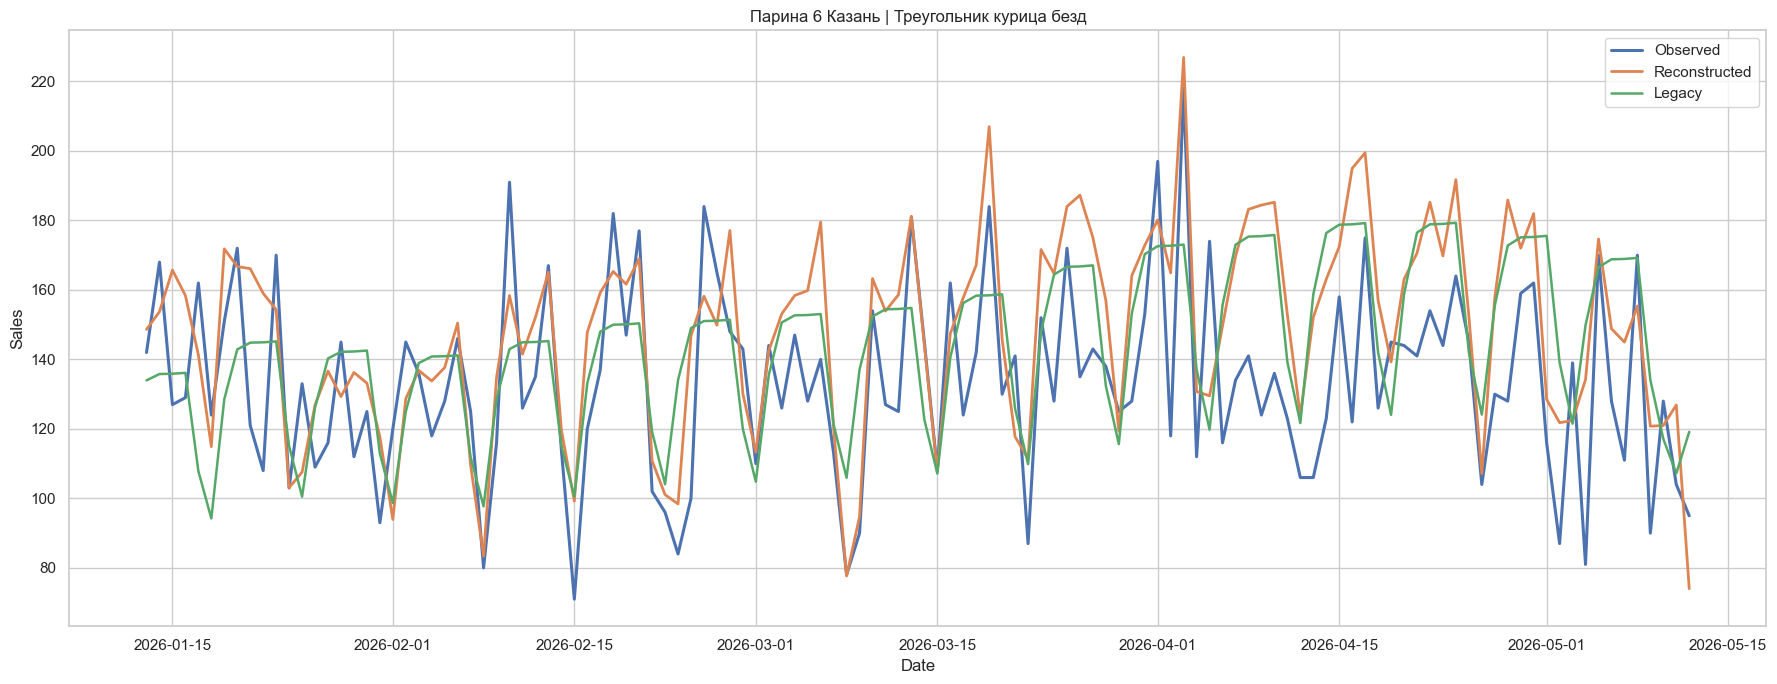

In [69]:
BAKERY_ID = 89
PRODUCT_ID = 1071

pair = temporal[
    (temporal["bakery_id"].astype(str) == str(BAKERY_ID))
    & (temporal["product_id"].astype(str) == str(PRODUCT_ID))
].copy().sort_values("date")

pair[["bakery_id", "bakery_name", "product_id", "product_name", "best_decomposition_path"]].drop_duplicates()
pair_tail = pair.tail(120)
fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(pair_tail["date"], pair_tail["observed_sales_qty"], label="Observed", linewidth=2.2)
ax.plot(pair_tail["date"], pair_tail["reconstructed_sales_qty"], label="Reconstructed", linewidth=2.0)
ax.plot(pair_tail["date"], pair_tail["temporal_normative_legacy_qty"], label="Legacy", linewidth=1.8)
# ax.plot(pair_tail["date"], pair_tail["temporal_normative_weekly_cv_qty"], label="Weekly CV", linewidth=1.8)
# ax.plot(pair_tail["date"], pair_tail["temporal_normative_flat_deviation_qty"], label="Flat Deviation", linewidth=1.8)
# ax.plot(pair_tail["date"], pair_tail["temporal_normative_reference_profile_qty"], label="Reference Profile", linewidth=2.0)
ax.set_title(f"{pair['bakery_name'].iloc[0]} | {pair['product_name'].iloc[0]}")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()

In [ ]:
pair_tail[[
    "date",
    "dow",
    "observed_sales_qty",
    "reconstructed_sales_qty",
    "sku_trend_normative",
    "long_weekday_share",
    "short_weekday_share",
    "share_delta_short_vs_long",
    "weekday_share_normative",
    "weekly_cv_raw",
    "weekly_cv_amplitude_multiplier",
    "weekly_cv_effective_strength",
    "flat_deviation_raw",
    "flat_deviation_amplitude_multiplier",
    "flat_deviation_effective_strength",
    "reference_profile_raw",
    "reference_profile_amplitude_multiplier",
    "reference_profile_effective_strength",
    "temporal_normative_legacy_qty",
    "temporal_normative_weekly_cv_qty",
    "temporal_normative_flat_deviation_qty",
    "temporal_normative_reference_profile_qty",
]].tail(30)

## Variant Diagnostics


In [ ]:
share_profile_view = (
    pair[[
        "dow",
        "long_weekday_share",
        "short_weekday_share",
        "weekday_share_normative",
        "share_delta_short_vs_long",
    ]]
    .drop_duplicates()
    .sort_values("dow")
)
share_profile_view

In [ ]:
plot_df = pair_tail[[
    "date",
    "weekly_cv_amplitude_multiplier",
    "weekly_cv_effective_strength",
    "flat_deviation_amplitude_multiplier",
    "flat_deviation_effective_strength",
    "reference_profile_amplitude_multiplier",
    "reference_profile_effective_strength",
]].drop_duplicates().melt(id_vars="date", var_name="variant", value_name="amplitude_multiplier")

fig, ax = plt.subplots(figsize=(18, 5))
sns.lineplot(data=plot_df, x="date", y="amplitude_multiplier", hue="variant", ax=ax)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Weekly amplitude multipliers")
plt.tight_layout()

In [ ]:
def plot_pair_variants(bakery_id: str | int, product_id: str | int, tail_days: int = 120) -> pd.DataFrame:
    pair = temporal[
        (temporal["bakery_id"].astype(str) == str(bakery_id))
        & (temporal["product_id"].astype(str) == str(product_id))
    ].copy().sort_values("date")
    if pair.empty:
        print("Pair not found")
        return pair

    view = pair.tail(tail_days)
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(view["date"], view["observed_sales_qty"], label="Observed", linewidth=2.2)
    ax.plot(view["date"], view["reconstructed_sales_qty"], label="Reconstructed", linewidth=2.0)
    ax.plot(view["date"], view["temporal_normative_legacy_qty"], label="Legacy", linewidth=1.8)
    ax.plot(view["date"], view["temporal_normative_weekly_cv_qty"], label="Weekly CV", linewidth=1.8)
    ax.plot(view["date"], view["temporal_normative_flat_deviation_qty"], label="Flat Deviation", linewidth=1.8)
    ax.plot(view["date"], view["temporal_normative_reference_profile_qty"], label="Reference Profile", linewidth=2.0)
    ax.set_title(f"{pair['bakery_name'].iloc[0]} | {pair['product_name'].iloc[0]}")
    ax.legend()
    plt.tight_layout()

    return pair[[
        "date",
        "observed_sales_qty",
        "reconstructed_sales_qty",
        "temporal_normative_legacy_qty",
        "temporal_normative_weekly_cv_qty",
        "temporal_normative_flat_deviation_qty",
        "temporal_normative_reference_profile_qty",
    ]].tail(tail_days)
